In [ ]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 6.8 MB/s eta 0:00:00


In [ ]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import mglearn

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

print("Size of Training set: {} \nSize of Test set: {}".format(X_train.shape[0], X_test.shape[0]))

Size of Training set: 112 
Size of Test set: 38


# Simple Grid Search

Below is a implementation of a simple grid search just as for loops over the two parameters, training and evaluating a classifier for each combination.

In [ ]:
best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters, train an SVC
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        # evaluate the SVC on the test set
        score = svm.score(X_test, y_test)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

print("Best score: {:.2f}".format(best_score))
print("Best parameters: {}".format(best_parameters))

Best score: 0.97
Best parameters: {'C': 100, 'gamma': 0.001}


#The Danger of Overfitting the Parameters and the Validation Set

Given this result, we might be tempted to report that we found a model that performs with 97% accuracy on our dataset. However, this claim could be overly optimistic (or just wrong), for the following reason: we tried many different parameters and selected the one with best accuracy on the test set, but this accuracy won’t necessarily carry over to new data. Because we used the test data to adjust the parameters, we can no longer use it to assess how good the model is. This is the same reason we needed to split the data into training and test sets in the first place; we need an independent dataset to evaluate, one that was not used to create the model.

One way to resolve this problem is to split the data again, so we have three sets: the training set to build the model, the validation (or development) set to select the parameters of the model, and the test set to evaluate the performance of the selected parameters.

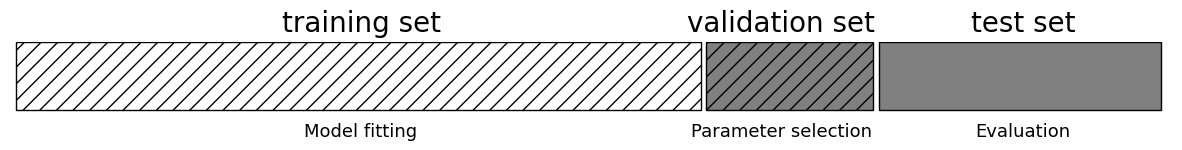

In [ ]:
mglearn.plots.plot_threefold_split()

After selecting the best parameters using the validation set, we can rebuild a model using the parameter settings we found, but now training on both the training data and the validation data. This way, we can use as much data as possible to build our model. This leads to the following implementation.

In [ ]:
# split data into train+validation set and test set
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, random_state=0)

# split train+validation set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, random_state=1)

print("Size of training set: {} \nSize of validation set: {} \nSize of test set: {}".format(X_train.shape[0], X_val.shape[0], X_test.shape[0]))

Size of training set: 84 
Size of validation set: 28 
Size of test set: 38


In [ ]:
best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters, train an SVC
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        # evaluate the SVC on the test set
        score = svm.score(X_val, y_val)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

print("Best score: {:.2f}".format(best_score))
print("Best parameters: {}".format(best_parameters))

Best score: 0.96
Best parameters: {'C': 10, 'gamma': 0.001}


In [ ]:

# rebuild a model on the combined training and validation set,
# and evaluate it on the test set
svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)
test_score = svm.score(X_test, y_test)
print("Test set score with best parameters: {:.2f}".format(test_score))

Test set score with best parameters: 0.92


The best score on the validation set is 96%: slightly lower than before, probably because we used less data to train the model (X_train is smaller now because we split our dataset twice). However, the score on the test set—the score that actually tells us how well we generalize—is even lower, at 92%. So we can only claim to classify new data 92% correctly, not 97% correctly as before!

 Any choices made based on the test set accuracy “leak” information from the test set into the model. Therefore, it is important to keep a separate test set, which is only used for the final evaluation.

# Grid Search with Cross-Validation

From the output of the previous code snippet we can see that grid search selects 'C': 10, 'gamma': 0.001 as the best parameters, while the output of the code in the previous section selects 'C': 100, 'gamma': 0.001 as the best parameters. For a better estimate of the generalization performance, instead of using a single split into a training and a validation set, we can use cross-validation to evaluate the performance of each parameter combination.

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters,
        # train an SVC
        svm = SVC(gamma=gamma, C=C)
        # perform cross-validation
        scores = cross_val_score(svm, X_trainval, y_trainval, cv=5)
        # compute mean cross-validation accuracy
        score = np.mean(scores)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

In [ ]:
# rebuild a model on the combined training and validation set
svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)

SVC(C=10, gamma=0.1)

To evaluate the accuracy of the SVM using a particular setting of C and gamma using five-fold cross-validation, we need to train 36 * 5 = 180 models. As you can imagine, the main downside of the use of cross-validation is the time it takes to train all these models.

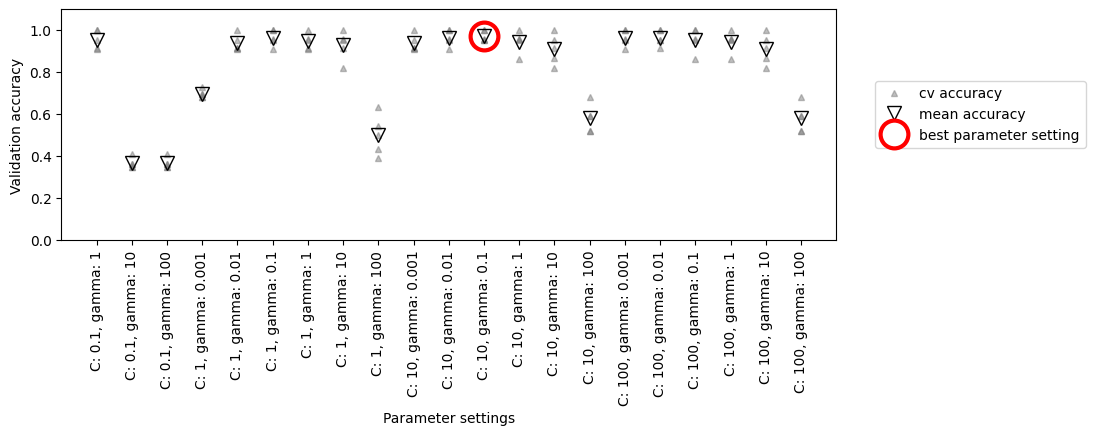

In [ ]:
mglearn.plots.plot_cross_val_selection()

For each parameter setting (only a subset is shown), five accuracy values are computed, one for each split in the cross-validation. Then the mean validation accuracy is computed for each parameter setting. The parameters with the highest mean validation accuracy are chosen, marked by the circle.

The overall process of splitting the data, running the grid search, and evaluating the final parameters is illustrated in below figure.

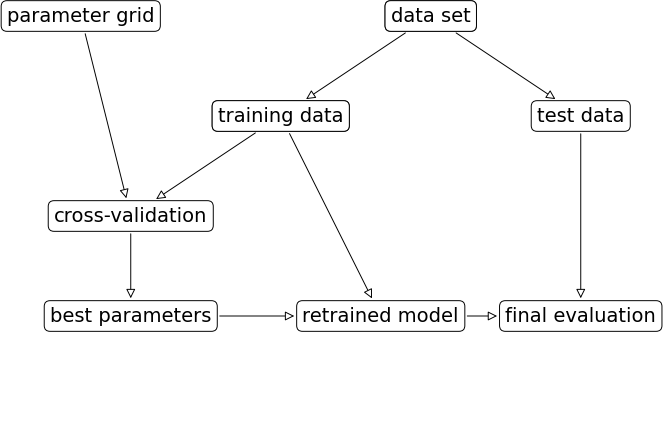

In [ ]:
mglearn.plots.plot_grid_search_overview()

Because grid search with cross-validation is such a commonly used method to adjust parameters, scikit-learn provides the GridSearchCV class, which implements it in the form of an estimator. To use the GridSearchCV class, you first need to specify the parameters you want to search over using a dictionary. GridSearchCV will then perform all the necessary model fits. The keys of the dictionary are the names of parameters we want to adjust (as given when constructing the model—in this case, C and gamma), and the values are the parameter settings we want to try out.

In [ ]:
param_grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100],
              'gamma':[0.001, 0.01, 0.1, 1, 10, 100]}

print("Parameter grid:\n{}".format(param_grid))

Parameter grid:
{'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}


We can now instantiate the GridSearchCV class with the model (SVC), the parameter grid to search (param_grid), and the cross-validation strategy we want to use (five-fold stratified cross-validation).

In [ ]:
from sklearn.model_selection import GridSearchCV

svc = SVC()

grid_search = GridSearchCV(svc, param_grid, cv=5, return_train_score=True)


GridSearchCV will use cross-validation in place of the split into a training and validation set that we used before. However, we still need to split the data into a training and a test set, to avoid overfitting the parameters.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

when we call fit, it will run cross-validation for each combination of parameters we specified in param_grid.

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
             return_train_score=True)

Fitting the GridSearchCV object not only searches for the best parameters, but also automatically fits a new model on the whole training dataset with the parameters that yielded the best cross-validation performance.

The GridSearchCV class provides a very convenient interface to access the retrained model using the predict and score methods. To evaluate how well the best found parameters generalize, we can call score on the test set.

In [ ]:
print("Test set Score: {:.2f}".format(grid_search.score(X_test, y_test)))

Test set Score: 0.97


Choosing the parameters using cross-validation, we actually found a model that achieves 97% accuracy on the test set. The important thing here is that we did not use the test set to choose the parameters. The parameters that were found are stored in the best_params_ attribute, and the best cross-validation accuracy (the mean accuracy over the different splits for this parameter setting) is stored in best_score_.

In [ ]:
print("Best Parameters: {}".format(grid_search.best_params_))
print("Best Score: {:.3f}".format(grid_search.best_score_))

Best Parameters: {'C': 10, 'gamma': 0.1}
Best Score: 0.973


To look at coefficients or feature importances. You can access the model with the best parameters trained on the whole training set using the best_estimator_ attribute

In [ ]:
print("Best estimator:\n{}".format(grid_search.best_estimator_))

Best estimator:
SVC(C=10, gamma=0.1)


Because grid_search itself has predict and score methods, using best_estimator_ is not needed to make predictions or evaluate the model.

# Analyzing the result of cross-validation

The results of a grid search can be found in the cv_results_ attribute, which is a dictionary storing all aspects of the search. It contains a lot of details, as you can see in the following output, and is best looked at after converting it to a pandas DataFrame.

In [ ]:
import pandas as pd

# convert to DataFrame
results = pd.DataFrame(grid_search.cv_results_)
display(results.head())

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.001765,0.000862,0.001482,0.001194,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.347826,0.347826,0.363636,...,0.366403,0.022485,22,0.370787,0.370787,0.366667,0.366667,0.355556,0.366092,0.005581
1,0.001392,0.000488,0.000845,0.000421,0.001,0.010,"{'C': 0.001, 'gamma': 0.01}",0.347826,0.347826,0.363636,...,0.366403,0.022485,22,0.370787,0.370787,0.366667,0.366667,0.355556,0.366092,0.005581
2,0.000881,0.000021,0.000566,0.000037,0.001,0.100,"{'C': 0.001, 'gamma': 0.1}",0.347826,0.347826,0.363636,...,0.366403,0.022485,22,0.370787,0.370787,0.366667,0.366667,0.355556,0.366092,0.005581
3,0.000896,0.000027,0.000551,0.000026,0.001,1.000,"{'C': 0.001, 'gamma': 1}",0.347826,0.347826,0.363636,...,0.366403,0.022485,22,0.370787,0.370787,0.366667,0.366667,0.355556,0.366092,0.005581
4,0.000877,0.000015,0.000538,0.000005,0.001,10.000,"{'C': 0.001, 'gamma': 10}",0.347826,0.347826,0.363636,...,0.366403,0.022485,22,0.370787,0.370787,0.366667,0.366667,0.355556,0.366092,0.005581


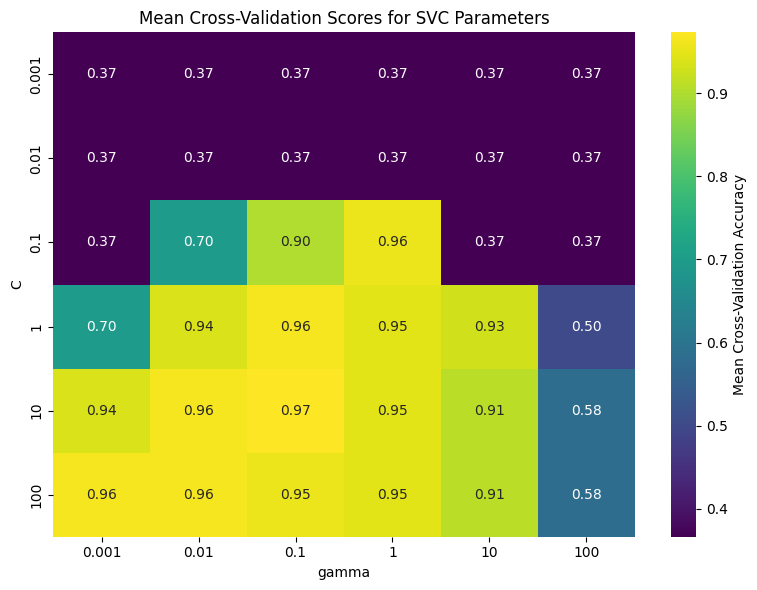

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure scores is a standard numpy array of floats with NaNs handled
scores = np.array(results.mean_test_score).reshape(6, 6)

# Create the heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(scores, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=param_grid['gamma'], yticklabels=param_grid['C'],
            cbar_kws={'label': 'Mean Cross-Validation Accuracy'})

plt.xlabel('gamma')
plt.ylabel('C')
plt.title('Mean Cross-Validation Scores for SVC Parameters')
plt.tight_layout()
plt.show()

Each point in the heat map corresponds to one run of cross-validation, with a particular parameter setting. The color encodes the cross-validation accuracy, with light colors meaning high accuracy and dark colors meaning low accuracy. You can see that SVC is very sensitive to the setting of the parameters. For many of the parameter settings, the accuracy is around 40%, which is quite bad; for other settings the accuracy is around 96%.

We can take away from this plot several things. First, the parameters we adjusted are very important for obtaining good performance. Both parameters (C and gamma) matter a lot, as adjusting them can change the accuracy from 40% to 96%. Additionally, the ranges we picked for the parameters are ranges in which we see significant changes in the outcome. It’s also important to note that the ranges for the parameters are large enough: the optimum values for each parameter are not on the edges of the plot.

# Search over spaces that are not grids

GridSearchCV allows the param_grid to be a list of dictionaries. Each dictionary in the list is expanded into an independent grid.

In [ ]:
param_grid = [{'kernel': ['rbf'],
              'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
              {'kernel': ['linear'],
               'C': [0.001, 0.01, 0.1, 1, 10, 100]}]

print("List of grids:\n{}".format(param_grid))

List of grids:
[{'kernel': ['rbf'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}, {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}]


In the first grid, the kernel parameter is always set to 'rbf', and both the C and gamma parameters are varied. In the second grid, the kernel parameter is always set to linear, and only C is varied.

In [ ]:
grid_search = GridSearchCV(SVC(), param_grid, cv=5, return_train_score=True)
grid_search.fit(X_train, y_train)

print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.97


In [ ]:
results = pd.DataFrame(grid_search.cv_results_)
# we display the transposed table so that it better fits on the page:
display(results.T)

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
mean_fit_time,0.002789,0.001548,0.0015,0.001552,0.002131,0.001687,0.001547,0.00178,0.001706,0.002758,...,0.001176,0.001462,0.001668,0.001875,0.001368,0.001216,0.001074,0.00147,0.001427,0.00108
std_fit_time,0.00126,0.000041,0.00012,0.000035,0.00107,0.000075,0.000089,0.000422,0.000354,0.001641,...,0.000217,0.000372,0.000043,0.000098,0.000176,0.000106,0.000049,0.000234,0.000174,0.00011
mean_score_time,0.001255,0.00105,0.001064,0.000985,0.000959,0.00105,0.000991,0.000898,0.000989,0.001857,...,0.001106,0.000934,0.001034,0.001028,0.000767,0.000809,0.000808,0.000866,0.000815,0.000819
std_score_time,0.000259,0.000069,0.000189,0.000012,0.000078,0.000084,0.000064,0.000071,0.000042,0.001058,...,0.000336,0.000143,0.00023,0.000025,0.000093,0.00006,0.00006,0.000097,0.000086,0.000199
param_C,0.001,0.001,0.001,0.001,0.001,0.001,0.01,0.01,0.01,0.01,...,100.0,100.0,100.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0
param_gamma,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,...,0.1,1.0,10.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN
param_kernel,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,...,rbf,rbf,rbf,rbf,linear,linear,linear,linear,linear,linear
params,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 1, 'kernel': 'rbf'}",...,"{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 10, 'kernel': 'rbf'}","{'C': 100, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.001, 'kernel': 'linear'}","{'C': 0.01, 'kernel': 'linear'}","{'C': 0.1, 'kernel': 'linear'}","{'C': 1, 'kernel': 'linear'}","{'C': 10, 'kernel': 'linear'}","{'C': 100, 'kernel': 'linear'}"
split0_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,...,1.0,0.956522,0.869565,0.521739,0.347826,0.869565,1.0,1.0,1.0,0.956522
split1_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,...,0.956522,0.956522,0.913043,0.521739,0.347826,0.869565,0.913043,0.956522,1.0,0.956522


# Nested cross-validation

 In nested cross-validation, there is an outer loop over splits of the data into training and test sets. For each of them, a grid search is run (which might result in different best parameters for each split in the outer loop). Then, for each outer split, the test set score using the best settings is reported.

In [ ]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}
scores = cross_val_score(GridSearchCV(SVC(), param_grid, cv=5),
                         iris.data, iris.target, cv=5)
print("Cross-validation scores: ", scores)
print("Mean cross-validation score: ", scores.mean())

Cross-validation scores:  [0.96666667 1.         0.96666667 0.96666667 1.        ]
Mean cross-validation score:  0.9800000000000001


The result of our nested cross-validation can be summarized as “SVC can achieve 98% mean cross-validation accuracy on the iris dataset”.

Here, we used stratified five-fold cross-validation in both the inner and the outer loop. As our param_grid contains 36 combinations of parameters, this results in a whopping 36 * 5 * 5 = 900 models being built, making nested cross-validation a very expensive procedure.